<a href="https://colab.research.google.com/github/rangaraju1/Generative-AI-and-LLM-Applications/blob/main/Using_LLMs_for_Retrieval_Augmented_Generation_(RAG)_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Proposed Solution**:

To address these challenges, we propose implementing a multimodal Retrieval-Augmented Generation (RAG) system tailored to the IPC Technical Manual dataset.

This will allow users to ask natural language questions and receive  context-grounded answers that integrate both textual and visual information from the manual.

By leveraging multimodal retrieval and generation, the system will enhance accessibility and understanding of the manual's complex content and will empower humanitarian actors to make faster, more informed decisions, improving the effectiveness of food security and nutrition interventions worldwide.


**Proposed Solution**:

To address these challenges, we propose implementing a multimodal Retrieval-Augmented Generation (RAG) system tailored to the IPC Technical Manual dataset.

This will allow users to ask natural language questions and receive  context-grounded answers that integrate both textual and visual information from the manual.

By leveraging multimodal retrieval and generation, the system will enhance accessibility and understanding of the manual's complex content and will empower humanitarian actors to make faster, more informed decisions, improving the effectiveness of food security and nutrition interventions worldwide.


<center><p float="center">
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>                                                                         <center><h1></h1></center>
<h1><left> <font size=5>MLS 5: Using LLMs for Retrieval-Augmented Generation (Part 2)</font></left></h1>

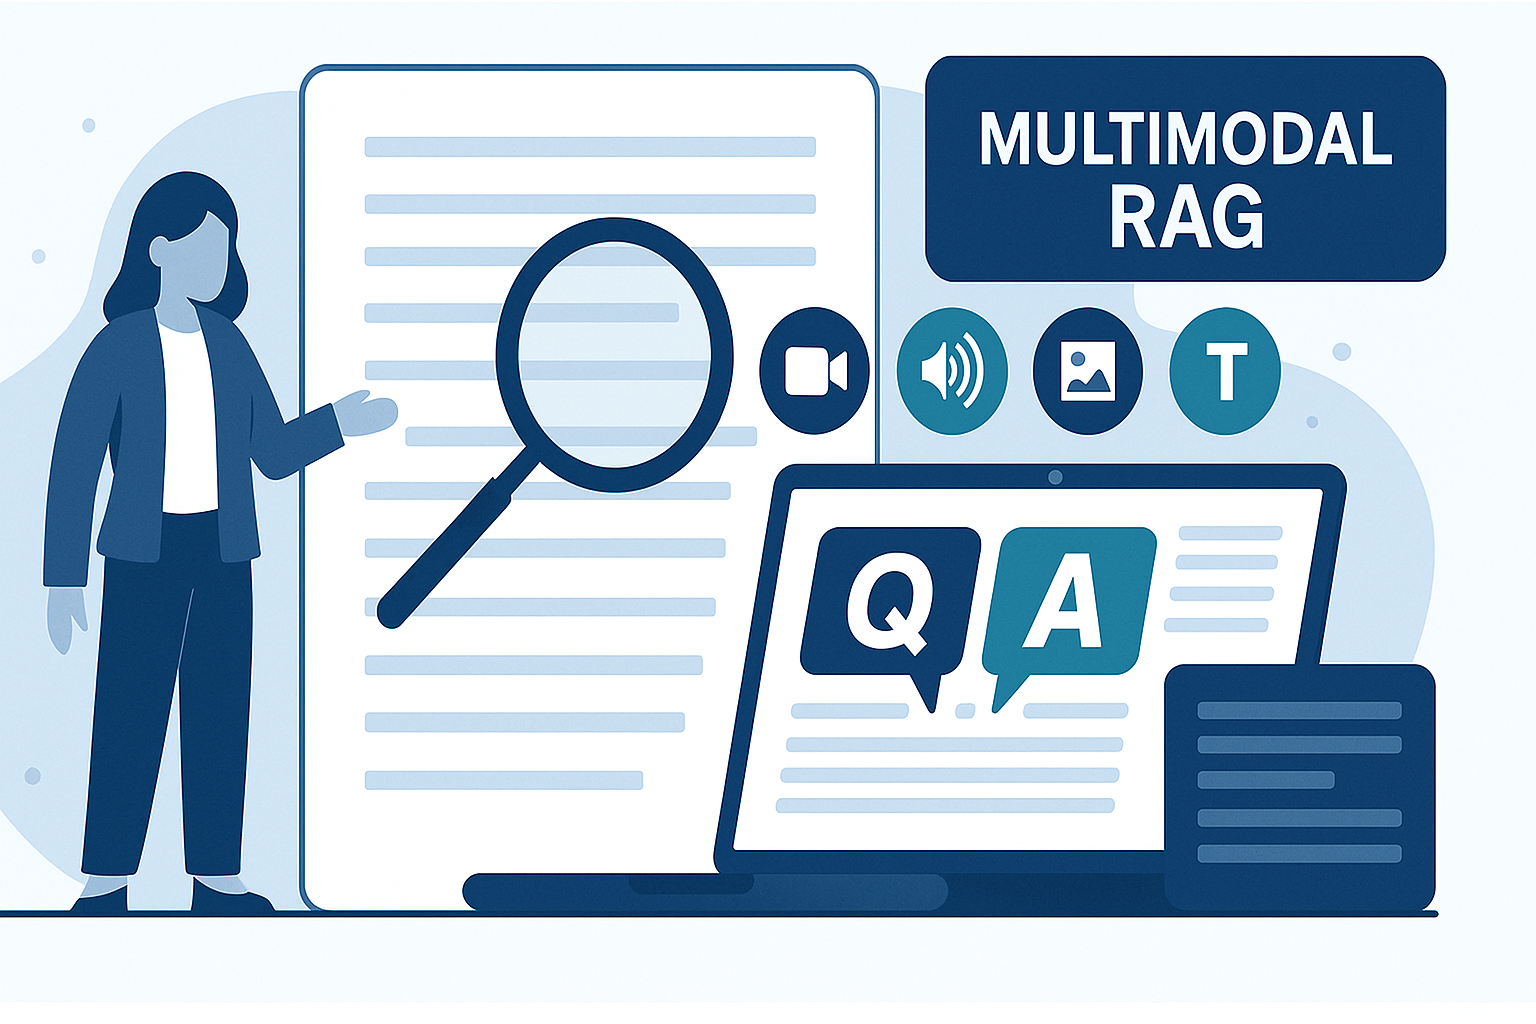

# Business Context

## Multi-Model RAG System

**Problem Scenario**:

The [Integrated Food Security Phase Classification (IPC)](https://www.ipcinfo.org/) is a global, multi-stakeholder initiative that enhances food security and nutrition analysis for informed decision-making.

Developed through collaboration among 15 expert organizations, the IPC Manual clarifies definitions like "Famine" and "Famine Likely" and strengthens evidence-based classification methods using international standards.

The manual is a complex resource containing detailed textual data, tables, charts, and diagrams.

Due to its multimodal and dense nature, analysts, policymakers, and field workers often find it challenging to quickly navigate and extract precise information, hindering timely and effective responses in food security and nutrition assessments.


# Objective

**Proposed Solution**:

To address these challenges, we propose implementing a multimodal Retrieval-Augmented Generation (RAG) system tailored to the IPC Technical Manual dataset.

This will allow users to ask natural language questions and receive  context-grounded answers that integrate both textual and visual information from the manual.

By leveraging multimodal retrieval and generation, the system will enhance accessibility and understanding of the manual's complex content and will empower humanitarian actors to make faster, more informed decisions, improving the effectiveness of food security and nutrition interventions worldwide.


We'll utilize LlamaParse to set up the document extraction process for tthe multimodal RAG pipeline.

The instructions to set up LlamaParse and set up an API Key is below.

## **<font color=blue> Setting up LlamaParse**

**Step 1**: Navigate to the following url - https://www.llamaindex.ai/llamaparse

**Step 2**: Click on the 'Get Started' button and click on the required sign in option.


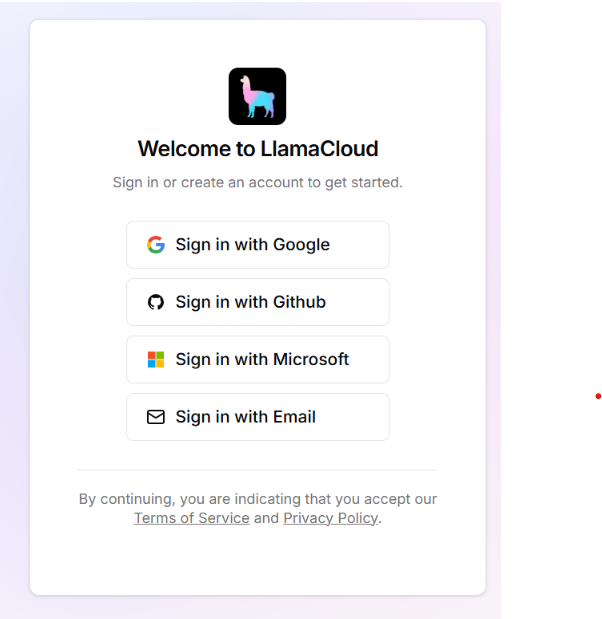

**Step 3**: Once you've entered the LlamaCloud dashboard, click on the 'API Keys' option.

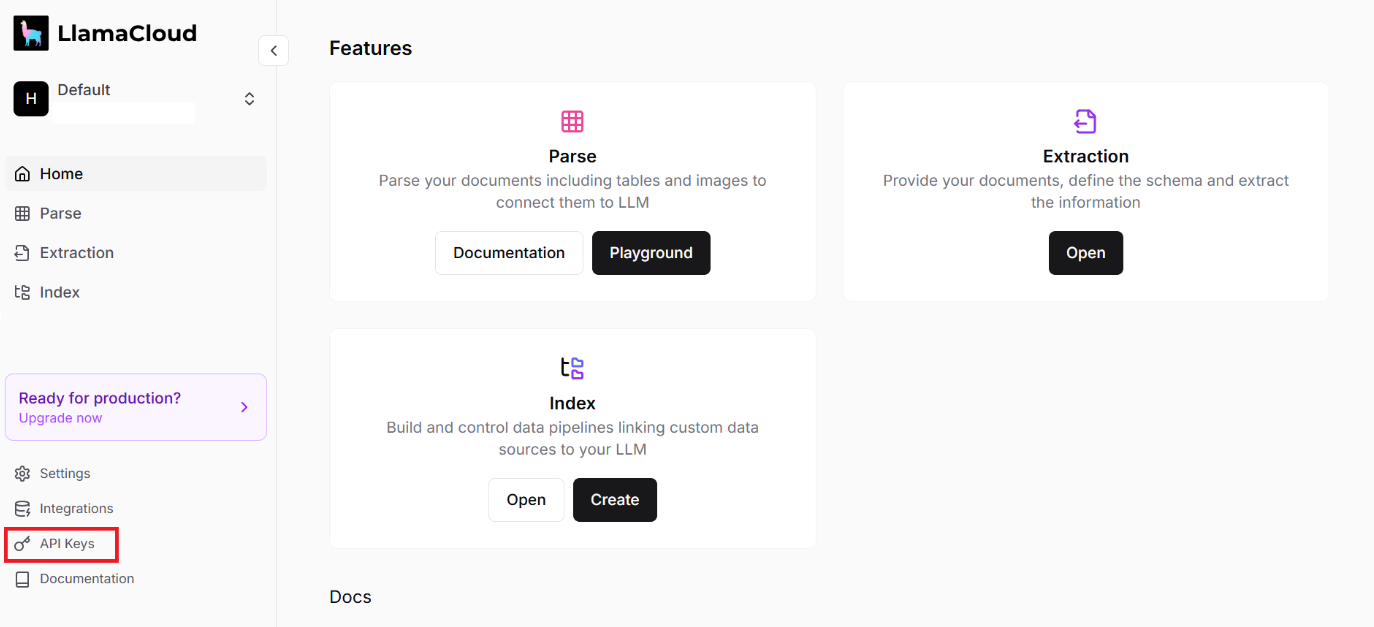

**Step 4**: Click on 'Generate New Key'

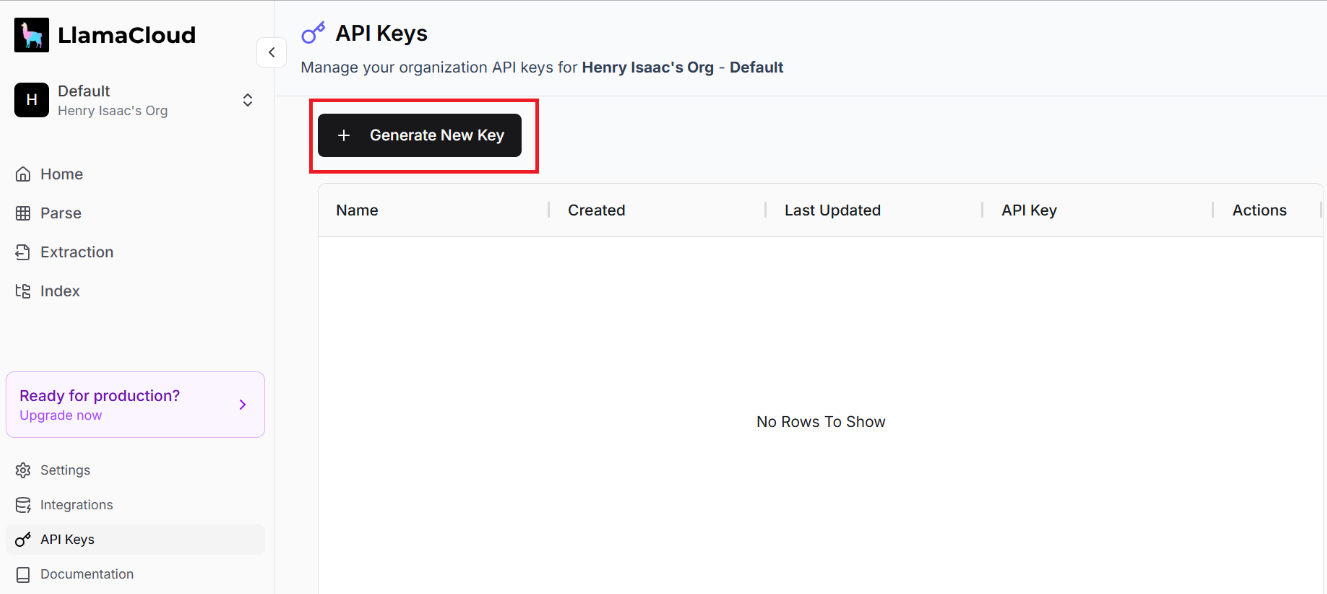

**Step 5**: Enter the corresponding details for the Secret Keys's name and click on 'Create secret key' to get the LlamaParse API Key

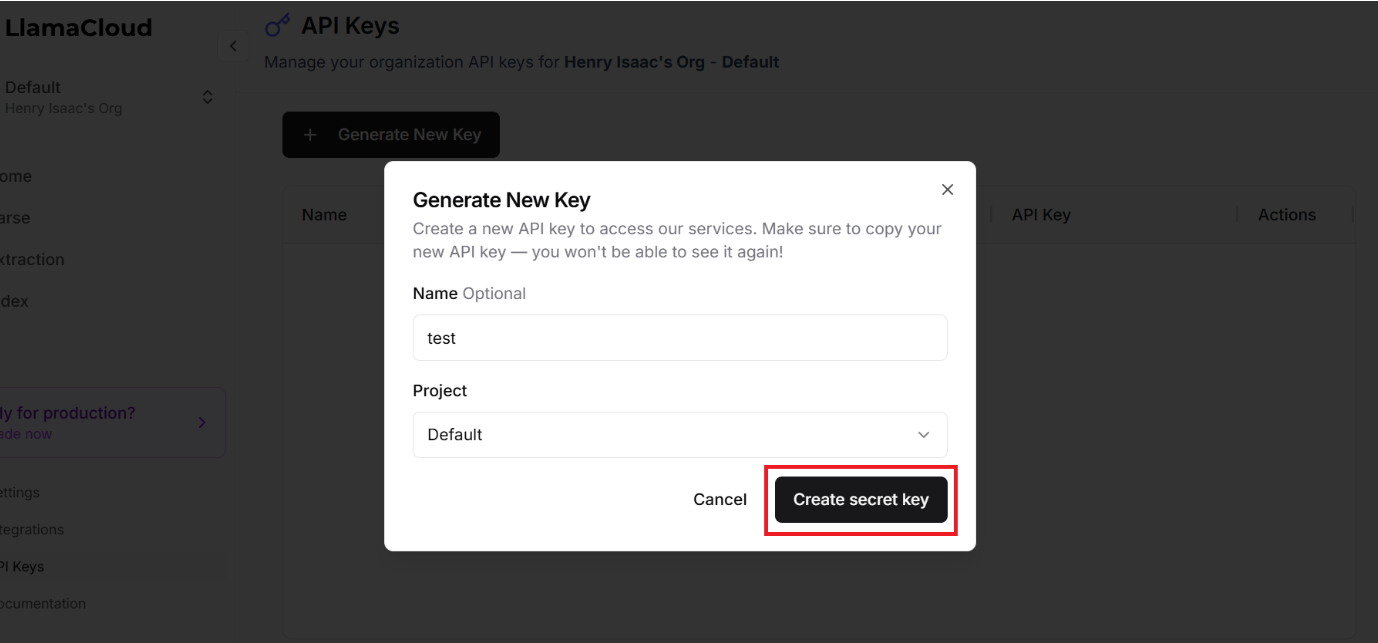

# Installing and Importing the Necessary Libraries

In this section, we install and import libraries required to run the notebook:

- The `openai` package provides the official OpenAI API client for accessing models like GPT-4, Whisper, DALL·E, including its embedding models

- The `tiktoken`	library provides access to OpenAI's tokenizer models, crucial for chunking and token counting

- The `pypdf` library parses and extracts text from PDF files — useful for document ingestion

- LangChain is a GenAI framework to build applications with LLMs using chains and agents.
  - `langchain` is the core library that provides access to various LangChain abstractions
  - `langchain-community` provides access to 3rd-party integrations (e.g., different vector stores, tools)
  - `langchain-chroma` provides specific integration to use ChromaDB as the vector store backend in LangChain
  - `langchain-openai` module provides a plug-in interface for LangChain to call OpenAI's LLMs using standardized interface

- `chromadb` library provides access to ChromaDB vector database, which is a fast, vector database optimized for retrieval in RAG systems

- `llama-parse` library enables unstructured documents to be parsed into structured formats (e.g., markdown, JSON) via LlamaParse Cloud.

- `deepeval` is an evaluation toolkit that can be used to assess quality, relevance, and faithfulness of LLM responses.

- `llama-index-core` is a python library for indexing and querying data using LLMs.

- `llama-index-readers-file` is a LlamaIndex module to load content from files like PDFs, TXT, DOCX, etc.

In [2]:
!uv pip install -qU numpy==2.1.0 \
                pandas==2.3.1 \
                openai==1.66.3 \
                tiktoken==0.9.0 \
                pypdf==5.4.0 \
                langchain==0.3.23 \
                langchain-community==0.3.19 \
                langchain-chroma==0.2.4 \
                langchain-openai==0.3.9 \
                langchain-cohere==0.4.4 \
                cohere==5.14 \
                chromadb==1.0.9 \
                lark==1.2.2 \
                llama-parse==0.6.23 \
                deepeval==2.9.2 \
                llama-index-core==0.12.29 \
                llama-index-readers-file==0.4.8 \
                pillow==11.3.0 \
                protobuf==3.20.*

Importing the relevant libraries

In [3]:
import base64
import os
from typing import List
import chromadb
from openai import OpenAI


from langchain_core.documents import Document
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
from langchain_cohere import CohereRerank
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import LLMChainExtractor
from langchain.retrievers.document_compressors import CrossEncoderReranker

from llama_parse import LlamaParse

from google.colab import userdata

from pprint import pprint

from deepeval import evaluate
from deepeval.test_case import LLMTestCase
from deepeval.dataset import EvaluationDataset
from deepeval.metrics import AnswerRelevancyMetric, FaithfulnessMetric, ContextualRelevancyMetric
from deepeval.metrics import ContextualPrecisionMetric, ContextualRecallMetric

import nest_asyncio; nest_asyncio.apply()

/usr/local/lib/python3.13/dist-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'validate_default' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'validate_default' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(


## Dataset Details

The `IPC Technical Manual Version 3.1` discusses evidence and standards for better food security and nutrition decisions. It contains more than 200 pages of text, tables, and images.

In [4]:
file_name = 'IPC_Technical_Manual_3'
pdf_file_path = file_name +'.pdf'
doc_info = "Integrated Food Security Phase Classification (IPC) Technical Report"

In [5]:
# input_doc_path = '/content/IPC_Technical_Manual_3.pdf'

Loading the API Keys from Colab secrets

In [6]:
openai_api_key = userdata.get('OPENAI_API_KEY')
llamaparse_api_key = userdata.get('llamaparse_api_key')

The following code adds the API Keys to the Environment Variables

In [8]:
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')

os.environ['OPENAI_BASE_URL'] =  "https://aibe.mygreatlearning.com/openai/v1"

os.environ['COHERE_API_KEY'] = userdata.get('cohere_api_key')

Defining the OpenAI client, the chat model and the embedding model.

In [9]:
# LLM model
model_name = 'gpt-4o-mini'  # Lightweight, fast version of GPT-4o optimized for performance

# Custom base URL for the OpenAI-compatible API endpoint (hosted by Great Learning)
base_url = "https://aibe.mygreatlearning.com/openai/v1"

# Instantiate the low-level OpenAI client with your API key and base URL
client = OpenAI(
    api_key=openai_api_key,  # Securely retrieved from environment or notebook
    base_url=base_url
)

# Initialize the ChatOpenAI LLM interface with specified model and parameters
llm = ChatOpenAI(
    api_key=openai_api_key,
    base_url=base_url,
    model=model_name,        # GPT-4o-mini for chat-based responses
    temperature=0.4          # Controls randomness: lower = more focused output
)

# Initialize the embedding model used for converting text to vector form
embedding_model = OpenAIEmbeddings(
    api_key=openai_api_key,
    base_url=base_url,
    model='text-embedding-3-small'  # Lightweight embedding model for efficient retrieval
)


## Multimodal Parsing using LlamaParse



To enable efficient parsing of multimodal PDF files, we utilize llamaparse, a service hosted on [LlamaCloud](https://cloud.llamaindex.ai/login).

Prior to processing documents, users must generate a LlamaCloud API key to authenticate requests.

Let us extract the text, images and tables from the pdf dataset.

In [10]:
parser = LlamaParse(
    result_type="markdown",
    parsing_instruction="Provided {}".format(doc_info),
    skip_diagonal_text=True,
    fast_mode=False,
    num_workers=9,
    check_interval=10,
    api_key=llamaparse_api_key
)


# Start parsing the file
json_objs = parser.get_json_result(pdf_file_path)

Started parsing the file under job_id 90b688c5-6166-459b-92a2-057af8cd047f
.

Parser uploads this pdf file onto [LlamaCloud](https://cloud.llamaindex.ai/login) where we can track progress of the parsing job. The different elements of the parsed PDF file can also be viewed.

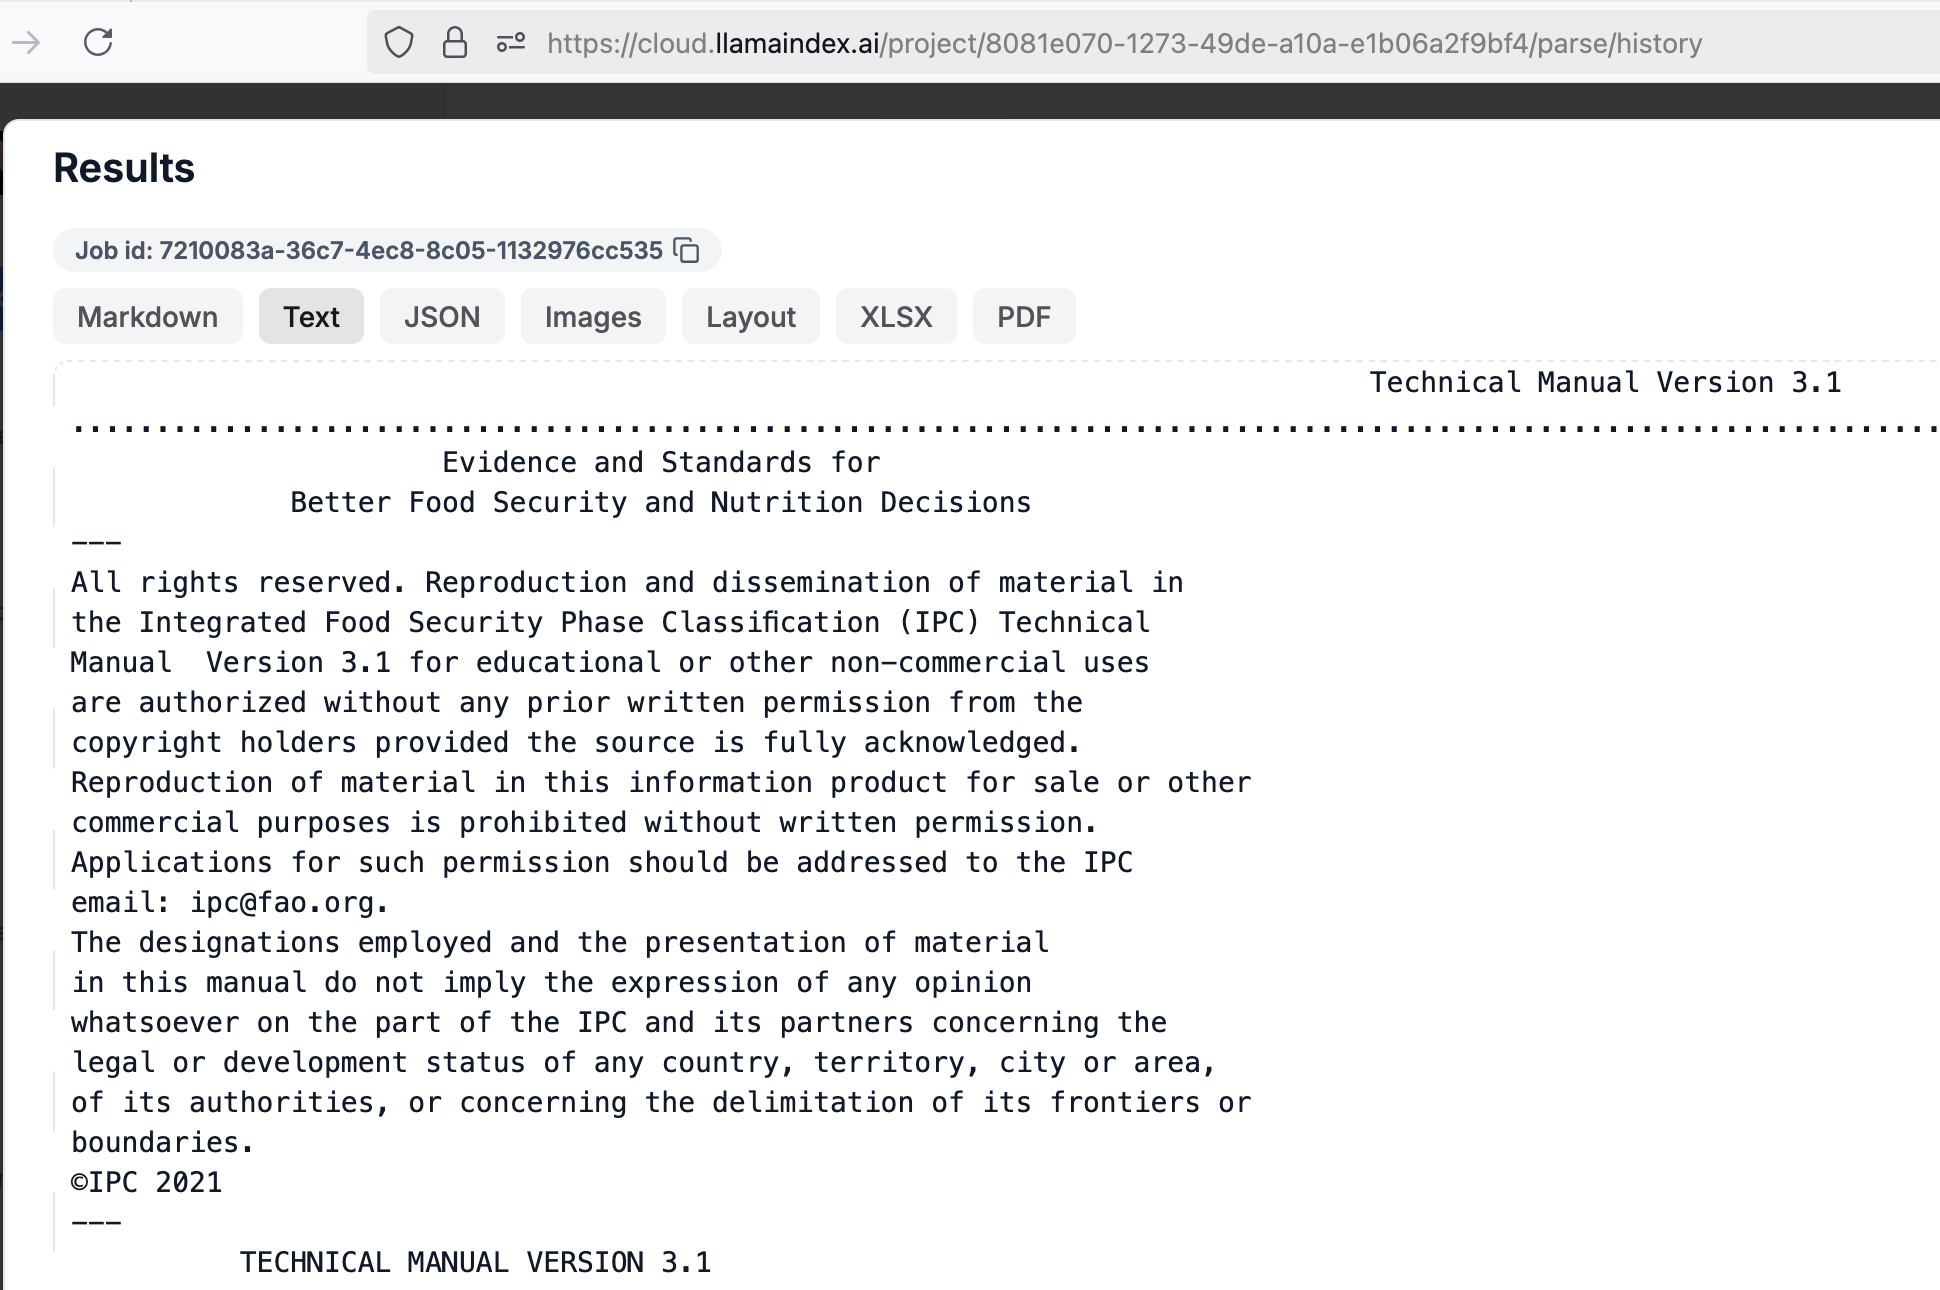

In [11]:
type(json_objs)

list

In [12]:
len(json_objs)

1

In [13]:
# Inspecting a parsed page
json_objs[0]['pages'][18]

{'page': 19,
 'text': '                                                                           IPC TECHNICAL MANUAL VERSION 3.1                          3\n\n                        1.1 WHAT THE IPC IS\n\n                        Figure 1: What the IPC is        The Integrated Food Security Phase Classification (IPC) is a common         PART 1: IPC OVERVIEW\n                                                         global scale for classifying the severity and magnitude of food\n                        The IPC is:                      insecurity and malnutrition. It is the result of a partnership of various\n                        • a process to build an          organizations at the global, regional and country levels dedicated\n                         evidence-based technical        to developing and maintaining the highest possible quality in food\n                         consensus among key             security and nutrition analysis. Increasingly, the IPC is the international\

`llamaparse` extracts document elements pagewise, storing text under `md` and `text`, images under `images`, and tables as type `table`.

Let us now extract the text and tables in the document by looping over the extracted pages.

In [14]:
# Extract page-wise content by iterating over the extracted pages.
pages_list = json_objs[0]["pages"]

In [15]:
# should match with number of pages in input pdf
len(pages_list)

229

In [ ]:
## To see the complete parsed output
# pages_list

### Extract Text

In [16]:
# Collecting all the text in the pages into a list by page.
page_texts = []

for json_item in pages_list:
    current_page_text = f"Page {json_item['page']}: \n" + json_item['md'] + '\n'
    page_texts.append(current_page_text)

len(page_texts)

229

In [17]:
# Inspecting text collected from a page
page_texts[9]

'Page 10: \nThe Integrated Food Security Phase Classification (IPC) Technical Manual Version 3.1 outlines various functions and protocols for assessing food security and malnutrition. Here’s a brief overview of the key sections:\n\n### Functions and Protocols Overview\n\n1. **Function 3: Communicate for Action**\n- **Protocol 3.1:** Produce the IPC Analysis Report\n- **Protocol 3.2:** Adhere to Mapping Standards\n- **Protocol 3.3:** Strategically Share Communication Products in a Timely Manner\n\n2. **Function 4: Quality Assurance**\n- **Protocol 4.1:** Conduct a Self-Assessment of the Analysis\n- **Protocol 4.2:** Request and Engage in an External Quality Review if Necessary\n\n3. **IPC Famine Classification**\n- Special Additional Protocols for areas with limited or no humanitarian access.\n\n4. **Chronic Food Insecurity Classification**\n- **Function 1:** Build Technical Consensus\n- **Protocol 1.1:** Compose the Analysis Team with Relevant Sectors and Organizations\n- **Protocol 1.

### Extract Tables & Generate Descriptions  

Next, we will extract the **cleanly** parsed tables from the `pages_list` followed by generating their descriptions.

In [18]:
tables = {}
for json_item in pages_list: # iterates through each page in the pages_list
    current_title = None # initializes current_title to None for each page
    for component in json_item['items']: # iterates through each component (e.g., heading, table) within a page
        if component['type'] == 'heading' and 'Table' in component['value']: # checks if the component is a heading and contains the word "Table"
            current_title = component['value'] # if true, assigns the heading value to current_title
        elif component['type'] == 'table' and current_title: # checks if the component is a table and current_title is not None (meaning a valid heading was found)
            tables[current_title] = component['rows'] # if true, adds the table data to the tables dictionary using current_title as the key
            current_title = None # resets current_title to None to avoid adding subsequent tables with the same title
pprint(list(tables.keys()))

['Population Table Example', 'IPC AFI Phase Table']


In [19]:
len(list(tables.keys()))

2

Let's inspect an extracted table.

In [20]:
tables.keys()

dict_keys(['Population Table Example', 'IPC AFI Phase Table'])

In [21]:
table_name =list(tables.keys())[0]
table_name

'Population Table Example'

In [22]:
pprint(tables[table_name])

[['Region',
  'Total Population',
  'Phase 1 (#people, %)',
  'Phase 2 (#people, %)',
  'Phase 3 (#people, %)',
  'Phase 4 (#people, %)',
  'Phase 5 (#people, %)',
  'Phase 3+ (#people, %)'],
 ['Region 1',
  '000,000',
  '000,000 (00%)',
  '000,000 (00%)',
  '000,000 (00%)',
  '000,000 (00%)',
  '000,000 (00%)',
  '000,000 (00%)'],
 ['Region 2',
  '000,000',
  '000,000 (00%)',
  '000,000 (35%)',
  '000,000 (00%)',
  '000,000 (00%)',
  '000,000 (00%)',
  '000,000 (00%)'],
 ['...', '...', '...', '...', '...', '...', '...', '...'],
 ['Grand Total',
  '00,000,000',
  '000,000 (00%)',
  '000,000 (00%)',
  '000,000 (00%)',
  '000,000 (00%)',
  '000,000 (00%)',
  '000,000 (00%)']]


Next, we will write a function to describe the rows of table as text in order to capture its contents.

In [23]:
def generate_table_description(tables, table_key):
    """Generates a description of a table using an OpenAI model.

    This function takes a dictionary of tables and a table key as input. It then
    constructs a prompt containing a system message and the table data.
    This prompt is sent to an OpenAI model, and the model's response is returned as
    the table description.

    Args:
        tables: A dictionary of tables.
        table_key: The key of the table to describe.

    Returns:
        A string containing the description of the table. If an error occurs
        during the OpenAI API call, an empty string is returned.
    """

    if table_key not in tables:
        return f"Error: Table key '{table_key}' not found in tables dictionary"

    table_describer_system_message = f"""
You are tasked to explain for {doc_info} document.
You are required to generate a detailed description of rows of tables presented to you as the input.
Be detailed in your description and describe ALL the rows of the table presented to you.
The input will contain the title of the table followed by a list of rows in the table.
Remember to include the title of the table in your output.
Do not add any text other than the title and the description of the table in your output.
"""

    table_description_prompt = [
        {'role': 'developer', 'content': table_describer_system_message},
        {'role': 'user', 'content': table_key + str(tables[table_key])}
    ]

    try:
        response = client.chat.completions.create(
            model=model_name,
            messages=table_description_prompt,
            temperature=0
        )
        description = response.choices[0].message.content
        return description
    except Exception as e:
        description = ''
        return description

In [24]:
# Generating the description of a table
pprint(generate_table_description(tables,table_name))

('Population Table Example\n'
 '\n'
 'This table presents a breakdown of the population across different regions, '
 'categorized by the Integrated Food Security Phase Classification (IPC) '
 'phases. The columns provide a comprehensive overview of the total population '
 'in each region, as well as the number and percentage of people classified '
 'under each IPC phase, which ranges from Phase 1 (minimal food insecurity) to '
 'Phase 5 (catastrophic food insecurity). \n'
 '\n'
 '- The first row serves as the header, indicating the categories of data '
 "included in the table: 'Region', 'Total Population', and the number and "
 'percentage of people in each IPC phase (Phase 1 through Phase 5), along with '
 'a cumulative total for those in Phase 3 and above (Phase 3+).\n'
 '\n'
 "- The second row details 'Region 1', with a total population of '000,000'. "
 "It shows that there are '000,000' people in Phase 1, which constitutes '00%' "
 'of the population. There are no individuals repor

In [25]:
# Generating description for all the extracted tables
table_descriptions_1 = []
table_descriptions_1 = [generate_table_description(tables, table_key) for table_key in tables.keys()]

In [27]:
table_descriptions_1[1]

"IPC AFI Phase Table\n\nThe IPC AFI Phase Table presents a structured overview of the population categorized by different phases of food security as defined by the Integrated Food Security Phase Classification (IPC). The table consists of three main columns: 'IPC AFI Phase', 'Current Population', and 'Projected Population'. \n\n1. The first row serves as the header, indicating the categories of data that will be presented in the subsequent rows. The 'IPC AFI Phase' column lists the various phases of food security, while the 'Current Population' and 'Projected Population' columns provide numerical data regarding the populations affected by each phase.\n\n2. The second row corresponds to the 'None' phase, which indicates that there is no food insecurity present. The 'Current Population' and 'Projected Population' for this phase are both marked as '000,000', suggesting that there are no individuals currently experiencing food insecurity and that this is expected to remain the case in the 

### Extract Images & Generate Descriptions

In [28]:
# Downloading all the parsed images
image_dicts = parser.get_images(
    json_objs,
    download_path="images"
)

> Images for page 1: [{'name': 'page_1.jpg', 'height': 841.89, 'width': 595.276, 'x': 0, 'y': 0, 'original_width': 1131, 'original_height': 1600, 'rotation': 0, 'type': 'full_page_screenshot'}]
> Images for page 2: [{'name': 'page_2.jpg', 'height': 841.89, 'width': 595.276, 'x': 0, 'y': 0, 'original_width': 1131, 'original_height': 1600, 'rotation': 0, 'type': 'full_page_screenshot'}]
> Images for page 3: [{'name': 'img_p2_1.jpg', 'height': 16.209, 'width': 16.275, 'x': 235.138, 'y': 734.229, 'original_width': 30, 'original_height': 30, 'rotation': 351}, {'name': 'img_p2_2.png', 'height': 24.687, 'width': 41.392, 'x': 337.252, 'y': 753.528, 'original_width': 78, 'original_height': 46, 'rotation': 0, 'ocr': [{'x': 1, 'y': 24, 'w': 76, 'h': 21, 'confidence': 0.992, 'text': 'for every child'}, {'x': 2, 'y': 3, 'w': 74, 'h': 21, 'confidence': 0.999, 'text': 'unicef'}]}, {'name': 'img_p2_3.png', 'height': 21.391, 'width': 54.45, 'x': 276.632, 'y': 754.8, 'original_width': 103, 'original_hei

Let us now look at the information available about a specific image.

In [29]:
image_dicts[0]

{'name': 'page_1.jpg',
 'height': 841.89,
 'width': 595.276,
 'x': 0,
 'y': 0,
 'original_width': 1131,
 'original_height': 1600,
 'rotation': 0,
 'type': 'full_page_screenshot',
 'path': 'images/90b688c5-6166-459b-92a2-057af8cd047f-page_1.jpg',
 'job_id': '90b688c5-6166-459b-92a2-057af8cd047f',
 'original_file_path': 'IPC_Technical_Manual_3.pdf',
 'page_number': 1}

Let us now write a function to generate a detailed description of an image.

In [30]:
def image_describer(image_file_path):
    """Generates a detailed description of an image using LLM.

    This function takes the file path of an image as input, reads the image data,
    encodes it to base64, and constructs a data URI. It then sends a prompt
    containing the image data URI to GPT-4o-mini. The model's
    response, which contains a detailed description of the image, is returned.

    Args:
        image_file_path: The file path of the image to describe.

    Returns:
        A string containing the description of the image generated
    """

    with open(image_file_path, 'rb') as image_file:
        image_data = image_file.read()

    # Encode the binary image data to base64
    base64_encoded_data = base64.b64encode(image_data).decode('utf-8')

    # Construct the data URI
    data_uri = f"data:image/png;base64,{base64_encoded_data}"

    image_description_system_message = f"""
    You are tasked to explain images present in the {doc_info} document.
    You are required to generate a detailed description of the image presented to you as the input.
    Be detailed in your description and describe the image presented to you.
    Do not add any text other than the description of the image in your output.
    """

    image_description_prompt = [
        {
            'role': 'system',
            'content': image_description_system_message
        },
        {
            'role': 'user',
            'content': [
                {'type': "image_url", "image_url": {'url': data_uri}}
            ]
        }
    ]

    response = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=image_description_prompt,
        temperature=0
    )

    return response.choices[0].message.content

Lets fetch the description of an image.

In [31]:
sample_image_path = image_dicts[4]['path']
image_describer(sample_image_path)

'The image features the logo of SICA, which stands for "Sistema de la Integración Centroamericana" (Central American Integration System). The logo includes a circular emblem with a stylized representation of a map or globe, featuring a green and blue color scheme. Surrounding the globe are decorative elements that suggest unity and integration. The acronym "SICA" is prominently displayed in bold letters, followed by the full name of the organization in a smaller font below. The overall design conveys a sense of collaboration among Central American countries.'

We shall now loop over all the paths of the downloaded images and create descriptions of all these images.

In [32]:
image_descriptions = [image_describer(image_info['path']) for image_info in image_dicts]

In [33]:
len(image_descriptions)

278

### Integrate Text, Tables & Images Descriptions

**Collecting all the text, table and image descriptions as single block of texts.**

In [34]:
# text
full_text = ''

for text in page_texts:
    full_text += ('\n---\n' + text)

# tables
all_table_descriptions = ''

for description in table_descriptions_1:
    all_table_descriptions += ('\n---\n' + description)

# images
all_image_descriptions = ''

for description in image_descriptions:
    all_image_descriptions += ('\n---\n' + description)

# defining text splitter
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=512,
    chunk_overlap=16
)

# adding the source of the text (i.e., document text, table or image) as metadata.
all_chunks = text_splitter.create_documents(
    [full_text, all_table_descriptions, all_image_descriptions],
    metadatas=[{'source': 'text'}, {'source': 'table_descriptions'}, {'source': 'image_descriptions'}]
)

In [35]:
len(all_chunks)

356

## RAG Q&A Application

As the multimodel data is chunked, we will use it to build a RAG Application over it.

We will create a Chroma vector database and populate it with records from the earlier created data chunks `all_chunks`

In [36]:
collection_name = file_name +'_collection'
db_path= "./"+file_name+"_db"

chromadb_client = chromadb.PersistentClient(
    path=db_path
)
# Creating a collection using Chroma client
vectorstore = Chroma(
    collection_name=collection_name,
    collection_metadata={"hnsw:space": "cosine"},
    embedding_function=embedding_model,
    client=chromadb_client,
    persist_directory=db_path
)
# confirming collection creation
chromadb_client.count_collections()

1

One collection is crated under `chromadb`

In [37]:
chromadb_client.list_collections()

[Collection(name=IPC_Technical_Manual_3_collection)]

Now we wil add the data(chunks) into vector DB

In [38]:
# Inserting each chunk with a unique id
unique_id_prefix= 'text_'

vectorstore.add_documents(
    documents=all_chunks,
    ids=[unique_id_prefix + str(i) for i in range(len(all_chunks))]
)

['text_0',
 'text_1',
 'text_2',
 'text_3',
 'text_4',
 'text_5',
 'text_6',
 'text_7',
 'text_8',
 'text_9',
 'text_10',
 'text_11',
 'text_12',
 'text_13',
 'text_14',
 'text_15',
 'text_16',
 'text_17',
 'text_18',
 'text_19',
 'text_20',
 'text_21',
 'text_22',
 'text_23',
 'text_24',
 'text_25',
 'text_26',
 'text_27',
 'text_28',
 'text_29',
 'text_30',
 'text_31',
 'text_32',
 'text_33',
 'text_34',
 'text_35',
 'text_36',
 'text_37',
 'text_38',
 'text_39',
 'text_40',
 'text_41',
 'text_42',
 'text_43',
 'text_44',
 'text_45',
 'text_46',
 'text_47',
 'text_48',
 'text_49',
 'text_50',
 'text_51',
 'text_52',
 'text_53',
 'text_54',
 'text_55',
 'text_56',
 'text_57',
 'text_58',
 'text_59',
 'text_60',
 'text_61',
 'text_62',
 'text_63',
 'text_64',
 'text_65',
 'text_66',
 'text_67',
 'text_68',
 'text_69',
 'text_70',
 'text_71',
 'text_72',
 'text_73',
 'text_74',
 'text_75',
 'text_76',
 'text_77',
 'text_78',
 'text_79',
 'text_80',
 'text_81',
 'text_82',
 'text_83',
 '

In [39]:
collection = chromadb_client.get_collection(collection_name)

In [40]:
# Count the number of records in the collection
collection.count()

356

In [41]:
# Inspect the first 2 records
collection.peek(limit=2)

{'ids': ['text_0', 'text_1'],
 'embeddings': array([[-0.00156212,  0.04675293,  0.06744385, ...,  0.03604126,
         -0.01635742,  0.00891113],
        [-0.0355835 ,  0.01317596,  0.08123779, ...,  0.05249023,
         -0.02250671, -0.00014555]]),
 'documents': ["---\nPage 1: \nIt seems that you've provided a snippet of a document related to a Technical Manual on food security and nutrition. If you have specific questions or need assistance with a particular section of the document, please let me know how I can help!\n\n---\nPage 2: \nThe Integrated Food Security Phase Classification (IPC) Technical Manual Version 3.1 is a resource that outlines the framework for classifying food security and nutrition situations. It is important to note that while reproduction and dissemination of the material for educational or non-commercial purposes are allowed with proper acknowledgment, any commercial use requires written permission from the IPC.\n\nThe manual emphasizes that the designations a

In [42]:
# To retrieve relevant records based on a user query
retriever = vectorstore.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 5}
)

In [43]:
user_query = "What causes malnutrition, and how can we effectively eliminate it? Mention in brief."

In [44]:
relevant_document_chunks = retriever.invoke(user_query)
context_list = [d.page_content for d in relevant_document_chunks]
context_for_query = "\n---\n".join(context_list)

In [45]:
context_for_query

'At the top, there are two main outcomes: "Mortality" and "Nutritional status," which are connected by arrows indicating their interrelation. Below these outcomes, the immediate causes are outlined, focusing on "Food consumption" and "Health status." Food consumption is described in terms of energy quantity and nutritional quality of food intake, while health status refers to the frequency and prevalence of diseases.\n\nThe next section details the underlying causes, which include "Food security dimensions" (with subcategories of food availability, food access, and household food utilization) and "Caring and feeding practices" (including infant and young child feeding practices and health-seeking behavior). Additionally, "Health services and environmental health" is mentioned, covering immunization, water and sanitation, and access to health services.\n\nAt the bottom of the chart, the basic causes are presented, which encompass "Acute events or ongoing conditions" and "Vulnerability, 

In [46]:
qna_system_message = f"""
You are an assistant who answers user queries about the {doc_info} document.
User input will include relevant context from the document to help you answer questions accurately.
The context will be delimited by: <Context> and </Context>.

User queries will be delimited by: <Question> and </Question>.

Follow these guidelines:
1. Answer questions **only** using the provided context. Do not speculate or invent details.
2. Keep answers concise and directly relevant to the question.
3. If the answer is not found in the context, respond: "I don't know."
4. Do not mention the context itself in your answer (e.g., avoid phrases like "According to the context...").
"""

qna_user_message_template = f"""
<Context>
Here are relevant excerpts from the {doc_info} Guide:
{{context}}
</Context>

<Question>
{{question}}
</Question>

Please answer the question using the context above. If the answer isn't available, say "I don't know."
"""

prompt = [
        {'role': 'developer', 'content': qna_system_message},
        {'role': 'user', 'content': qna_user_message_template.format(
            context=context_for_query,
            question=user_query
            )
        }
    ]

try:
    response = client.chat.completions.create(
            model=model_name,
            messages=prompt,
            temperature=0
        )

    prediction = response.choices[0].message.content.strip()
except Exception as e:
        prediction = f'Sorry, I encountered the following error: \n {e}'




In [47]:
prediction

'Malnutrition is caused by a complex interplay of factors, including immediate causes such as health status (e.g., common childhood illnesses like malaria and diarrhoea) and food consumption (quality and quantity of food). Underlying causes include caring and feeding practices, health services and environmental health, and food security dimensions (availability, access, utilization, and stability). Basic causes encompass broader issues like vulnerability, resources, control, and socio-economic inequalities.\n\nTo effectively eliminate malnutrition, it is essential to address these factors through comprehensive strategies that include improving food security, enhancing health services, promoting proper caring and feeding practices, and addressing socio-economic inequalities.'

Modularising the above code into two functions.
- `retrieve_rag_context` : For retrieving the relevant context from the VectorDB for a given user query.

- `generate_rag_answer`: For inferring the answer of the given user query from the retrieved context

These functions will be used in subsequent sections for context retrieval and answer generation, respectively.

In [48]:
def retrieve_rag_context(
    user_query: str,
    retriever=retriever
) -> list[str]:
    """
    Retrieves relevant document chunks using RAG.

    Args:
        user_query: Input question or query.
        retriever: The retriever object for querying the vector store.

    Returns:
        list: List of retrieved context strings.
    """
    try:
        relevant_document_chunks = retriever.invoke(user_query)
        return [d.page_content for d in relevant_document_chunks]

    except Exception as e:
        print(f"Error retrieving context: {str(e)}")
        return []

In [49]:
def generate_rag_answer(
    user_query: str,
    context_list: list[str],
    client=client,
    model_name=model_name,
    system_prompt=qna_system_message,
    user_prompt_template=qna_user_message_template
) -> str:
    """
    Generates a response using LLM based on retrieved context.

    Args:
        user_query: Input question or query.
        context_list: List of context strings retrieved by RAG.
        client: Client for the LLM API.
        model_name: Name of the LLM model to use.
        system_prompt: Template for the LLM system message.
        user_prompt_template: Template for the user message.

    Returns:
        str: Generated response from LLM
    """
    try:
        context_for_query = "\n---\n".join(context_list)

        # Prepare prompt
        prompt = [
            {'role': 'developer', 'content': system_prompt},
            {'role': 'user', 'content': user_prompt_template.format(
                context=context_for_query,
                question=user_query
            )}
        ]

        # Get LLM response
        response = client.chat.completions.create(
            model=model_name,
            messages=prompt,
            temperature=0
        )

        return response.choices[0].message.content.strip()

    except Exception as e:
        return f'Sorry, I encountered an error: {str(e)}'

Let's test these functions.

In [50]:
# Usage test
user_query = "What causes malnutrition, and how can we effectively eliminate it? Mention in brief."
contexts = retrieve_rag_context(user_query)
contexts

['At the top, there are two main outcomes: "Mortality" and "Nutritional status," which are connected by arrows indicating their interrelation. Below these outcomes, the immediate causes are outlined, focusing on "Food consumption" and "Health status." Food consumption is described in terms of energy quantity and nutritional quality of food intake, while health status refers to the frequency and prevalence of diseases.\n\nThe next section details the underlying causes, which include "Food security dimensions" (with subcategories of food availability, food access, and household food utilization) and "Caring and feeding practices" (including infant and young child feeding practices and health-seeking behavior). Additionally, "Health services and environmental health" is mentioned, covering immunization, water and sanitation, and access to health services.\n\nAt the bottom of the chart, the basic causes are presented, which encompass "Acute events or ongoing conditions" and "Vulnerability,

In [51]:
generate_rag_answer(user_query,contexts)

'Malnutrition is caused by a complex interplay of factors, including immediate causes such as health status (e.g., common childhood illnesses like malaria and diarrhoea) and food consumption (quality and quantity of food). Underlying causes include caring and feeding practices, health services and environmental health, and food security dimensions (availability, access, utilization, and stability). Basic causes encompass broader issues like vulnerability, resources, control, and socio-economic inequalities.\n\nTo effectively eliminate malnutrition, it is essential to address these factors through comprehensive strategies that include improving food security, enhancing health services, promoting proper caring and feeding practices, and addressing socio-economic inequalities. This requires coordinated efforts across various sectors to ensure that all contributing factors are considered and addressed.'

## RAG Evaluation  

RAG application evaluation employs approaches depending on the availability/unavailability of Ground truth data.

Ground truth refers to the validated correct responses to user queries, also called gold answers. Multiple queries paired with their golden responses collectively form a Golden dataset, which shall be used as a benchmark to assess the quality of generated answers in RAG systems


A typical evaluation test case consist of,
 - User query
 - RAG generated response
 - Baseline validated answer(optional)

To evaluate RAG, one among below two RAG evaluation frameworks shall be used:

1. RAG Triad
2. RAGAS (**Retrieval Augmented Generation Assessment**)

Both frameworks provide holistic evaluation by combining multiple distinct metrics to score the performance of a RAG pipeline’s retriever and generator.



**RAG Triad Metrics**:
- **Answer Relevanc**e : Measures how well the final response answers the original question, ensuring the answer is on-topic and appropriate.
- **Faithfulness** (Groundedness) : Assesses whether the generated answer is well-supported by the retrieved context, checks for hallucinations or unsupported claims.
- **Contextual Relevance** : Evaluates how relevant the retrieved context is to the original query.


**RAGAS Metrics**:
- **Answer Relevancy** : Measures how relevant the generated answer is.
- **Faithfulness**: Assesses the factual accuracy of the answer relative to the retrieved context.
- **Contextual Precision** : Evaluates the precision of the retrieved context*.
- **Recall**: Measures the recall quality of the retrieved context*.

Note that a Golden answer is needed to measure Contextual Precision and Recall; hence, RAGAS evaluation is recommended when Golden example(s) are available.

### DeepEval
DeepEval is an open-source LLM evaluation framework that offers ready-to-use implementations of the metrics discussed above. Additionally, both generation and retrieval capabilities can be refined in order to improve and optimize evaluation scores.

Next, we will evaluate our RAG architecture using the RAG Triad.

**Considering we do not have any Golden output.**


### RAG Triad

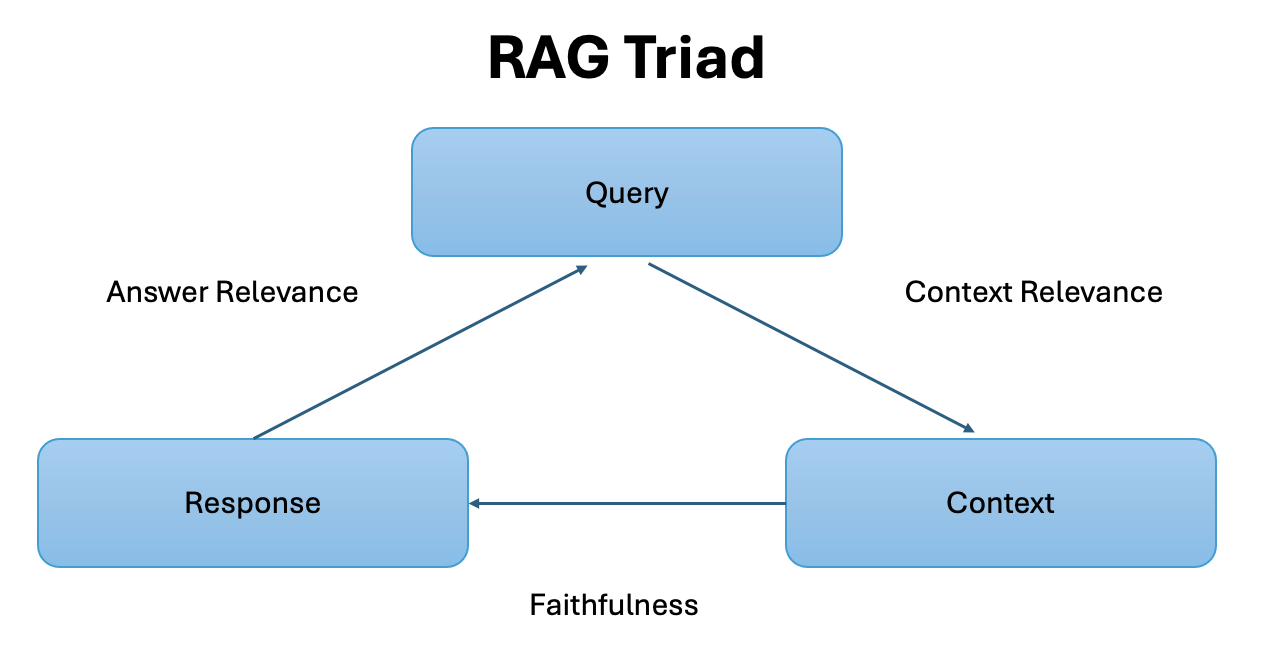

Lets first initialise the 3 metrics that RAG Triad uses.
The `threshold` parameter here, defines the minimum acceptable standard for an answer to pass evaluation against the chosen metric.

In [52]:
answer_relevancy = AnswerRelevancyMetric(
    threshold=0.7,
    model='gpt-4o',
    include_reason=True
)

#Groundedness
faithfulness = FaithfulnessMetric(
    threshold=0.7,
    model='gpt-4o',
    include_reason=True
)

contextual_relevancy = ContextualRelevancyMetric(
    threshold=0.7,
    model='gpt-4o',
    include_reason=True
)

#### Evaluate without Ground truth

**Single Test Case**

In [53]:
user_query = "Define a metric to measure malnutrition."
retrieved_context = retrieve_rag_context(user_query)
retrieved_context

['2. **Immediate Causes**: This section lists various immediate causes of acute malnutrition, including:\n   - Minimum dietary diversity (MDD)\n   - Minimum meal frequency (MMF)\n   - Minimum acceptable diet (MAD)\n   - Specific health issues such as diarrhea, malaria, and measles.\n\n3. **Underlying Causes**: This section outlines factors that contribute to malnutrition, such as:\n   - Health-seeking behavior\n   - Access to clean water and sanitation\n   - Coverage of vaccination programs.\n\n4. **Basic Causes**: This part includes broader categories like:\n   - Human, physical, financial, natural, and social capital.\n   - Policies and processes that may affect food security.\n\n5. **Other Issues**: This section highlights additional factors, including:\n   - Rates of anemia among different demographics\n   - Fertility rates\n   - Child mortality rates.\n\n6. **Notes**: At the bottom, there are notes providing context and definitions for some of the indicators listed, emphasizing th

In [54]:
answer = generate_rag_answer(user_query,retrieved_context)
answer

'A metric to measure malnutrition is the Global Acute Malnutrition (GAM) based on Weight-for-Height Z score (WHZ) and Mid-Upper Arm Circumference (MUAC). WHZ is used primarily, while MUAC is applied only in the absence of WHZ data.'

To construct a test case, we will utilize the `LLMTestCase` abstraction provided by the `deepeval` framework.

In [55]:
test_case_without_golden_output = LLMTestCase(
    input=user_query,
    actual_output=answer,
    retrieval_context=retrieved_context
)

The performance of the RAG system can be evaluated against the test case using `evaluate` function call.

In [56]:
results = evaluate(
    test_cases=[test_case_without_golden_output],
    metrics=[answer_relevancy, faithfulness, contextual_relevancy]
)

✨ You're running DeepEval's latest Answer Relevancy Metric! (using gpt-4o, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Faithfulness Metric! (using gpt-4o, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Contextual Relevancy Metric! (using gpt-4o, strict=False, async_mode=True)...

Evaluating 1 test case(s) in parallel: |          |  0% (0/1) [Time Taken: 00:00, ?test case/s]

False !!!!!!!!!!!!
False !!!!!!!!!!!!


Evaluating 1 test case(s) in parallel: |██████████|100% (1/1) [Time Taken: 00:11, 11.58s/test case]

False !!!!!!!!!!!!


Metrics Summary

  - ✅ Answer Relevancy (score: 1.0, threshold: 0.7, strict: False, evaluation model: gpt-4o, reason: The score is 1.00 because the output perfectly addresses the input without any irrelevant statements, providing a clear and concise definition of a metric to measure malnutrition. Great job on staying focused and relevant!, error: None)
  - ✅ Faithfulness (score: 1.0, threshold: 0.7, strict: False, evaluation model: gpt-4o, reason: The score is 1.00 because there are no contradictions present, indicating a perfect alignment between the actual output and the retrieval context. Great job maintaining accuracy and consistency!, error: None)
  - ❌ Contextual Relevancy (score: 0.6, threshold: 0.7, strict: False, evaluation model: gpt-4o, reason: The score is 0.60 because while the retrieval context provides some relevant information on metrics like Global Acute Malnutrition (GAM) based on Weight-for-Height Z score (WHZ) and Mid-Upper Arm Circumference (MU

✓ Tests finished 🎉! Run 'deepeval login' to save and analyze evaluation results on Confident AI.
 
✨👀 Looking for a place for your LLM test data to live 🏡❤️ ? Use Confident AI to get & share testing reports, 
experiment with models/prompts, and catch regressions for your LLM system. Just run 'deepeval login' in the CLI.

 **Observation : '*Contextual Relevancy*' score  is less than desired threshold here.Hence, it needs improvement.**

Above evaluation codes has been modularized into the `rag_triad_evaluation` function next, by which the RAG architecture is evaluated using the RAG triad approach. A user query, RAG response context list, and an optional golden answer are required as inputs. Both scenarios—with and without a golden answer—are incorporated to ensure generality. This method will be leveraged for RAG evaluation in subsequent sections.

In [57]:
def rag_triad_evaluation(user_input: str,
                         prediction: str,
                         context_list: list,
                         golden_output: str = None):
    """
    Evaluate RAG performance using multiple metrics.

    Args:
        user_input (str): The input query/prompt given to the RAG system
        prediction (str): The output generated by the RAG system
        context_list (list): List of context chunks used for retrieval
        golden_output (str, optional): The expected/ideal output. Defaults to None.

    Returns:
        dict: Evaluation results containing metrics scores
    """
    # Default golden output if not provided
    if golden_output is None:
      #test_case_withour_golden_output
      test_case = LLMTestCase(
        input=user_input,
        actual_output=prediction,
        retrieval_context=context_list
    )

    else:
      test_case = LLMTestCase(
        input=user_input,
        expected_output=golden_output,
        actual_output=prediction,
        retrieval_context=context_list
    )

    # Evaluate metrics
    results = evaluate(
        test_cases=[test_case],
        metrics=[answer_relevancy, faithfulness, contextual_relevancy]
    )

    return None

**Batch Evaluation**

Let's now perform the evaluation on a list containing multiple questions.

In [58]:
test_queries = [
    "What are the main causes of acute food insecurity in crisis areas?",
    "Quantify adequate vs inadequate food intake?",
    "What are the 3 most effective solution to eradicate poverty" ]

for user_query in test_queries :
    retrieved_context = retrieve_rag_context(user_query)
    actual_output = generate_rag_answer(user_query,retrieved_context)
    rag_triad_evaluation(user_query,actual_output, retrieved_context)

✨ You're running DeepEval's latest Answer Relevancy Metric! (using gpt-4o, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Faithfulness Metric! (using gpt-4o, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Contextual Relevancy Metric! (using gpt-4o, strict=False, async_mode=True)...

Evaluating 1 test case(s) in parallel: |          |  0% (0/1) [Time Taken: 00:00, ?test case/s]

False !!!!!!!!!!!!
False !!!!!!!!!!!!


...

Evaluating 1 test case(s) in parallel: |          |  0% (0/1) [Time Taken: 00:00, ?test case/s]

False !!!!!!!!!!!!
False !!!!!!!!!!!!


Evaluating 1 test case(s) in parallel: |██████████|100% (1/1) [Time Taken: 00:09,  9.86s/test case]

False !!!!!!!!!!!!


Metrics Summary

  - ✅ Answer Relevancy (score: 1.0, threshold: 0.7, strict: False, evaluation model: gpt-4o, reason: The score is 1.00 because the response perfectly addressed the question by providing three effective solutions to eradicate poverty without any irrelevant information. Great job on staying focused and relevant!, error: None)
  - ✅ Faithfulness (score: 1.0, threshold: 0.7, strict: False, evaluation model: gpt-4o, reason: The score is 1.00 because there are no contradictions present, indicating a perfect alignment between the actual output and the retrieval context. Great job maintaining accuracy and consistency!, error: None)
  - ❌ Contextual Relevancy (score: 0.23809523809523808, threshold: 0.7, strict: False, evaluation model: gpt-4o, reason: The score is 0.24 because the retrieval context primarily addresses food insecurity and its contributing factors, rather than directly providing solutions to eradicate poverty. While the context mentions the n

✓ Tests finished 🎉! Run 'deepeval login' to save and analyze evaluation results on Confident AI.
 
✨👀 Looking for a place for your LLM test data to live 🏡❤️ ? Use Confident AI to get & share testing reports, 
experiment with models/prompts, and catch regressions for your LLM system. Just run 'deepeval login' in the CLI.

Clearly, the RAG Architecture needs improvements in its  **Contextual Relevancy** capability.
Hence, lets try to enhance retrival performance of our RAG Architecture.

## Enhancing Retrieval Performance

### Query Expansion

In this apprach, the LLM is asked to generate variations of the original user query. Each of these variations is then used to retrieve the relevant context. The final context used is the unique set of documents retrieved across all the query expansions.

Below function implements *Query Expansion* approach.

In [59]:
def query_expansion(
    user_input: str,
    doc_info: str = doc_info,
    llm: ChatOpenAI = llm,
    no_of_variations: int = 3  # Default to 3 if not specified
) -> List[str]:
    """
    Expands a user's query into multiple variations using an LLM and retrieves relevant documents.

    Args:
        user_input: The original user question.
        doc_info: Context for the LLM.
        llm: Initialized ChatOpenAI instance.
        no_of_variations: Number of query variations to generate (default: 3).

    Returns:
        List of unique document contexts retrieved from the expanded queries.
    """
    # System prompt with dynamic doc_details and no_of_questions
    query_expansion_system_message = f"""
    You are a support assistant who answers user queries about the {doc_info}.
    Perform query expansion on the question below. If there are multiple common ways of phrasing a user question \
    or common synonyms for key words in the question, make sure to return multiple versions \
    of the query with the different phrasings.

    If there are acronyms or words you are not familiar with, do not try to rephrase them.

    Return {no_of_variations} versions of the question as a list.
    Generate only a list of questions, each question in a new line.
    Do not number the list of questions or use bullet points.
    Do not mention anything before or after the list.
    """

    # User message template
    user_message_template = """
    <Question>
    {question}
    </Question>
    """

    # Generate query expansions via LLM
    query_expansions = llm.invoke([
        ('system', query_expansion_system_message),
        ('user', user_message_template.format(question=user_input))
    ])

    # Parse LLM output into a list of queries
    query_expansions_list = query_expansions.content.strip().split("\n")

    # Retrieve documents for each expanded query
    expanded_context_list = []
    for query in query_expansions_list:
        expanded_context_list.extend([d.page_content for d in retriever.invoke(query)])

    # Remove duplicates and return
    return list(set(expanded_context_list))

In [60]:
user_query = "Define a metric to measure malnutrition."
context_list  = query_expansion(user_query)
context_list

['At the top, there are two main outcomes: "Mortality" and "Nutritional status," which are connected by arrows indicating their interrelation. Below these outcomes, the immediate causes are outlined, focusing on "Food consumption" and "Health status." Food consumption is described in terms of energy quantity and nutritional quality of food intake, while health status refers to the frequency and prevalence of diseases.\n\nThe next section details the underlying causes, which include "Food security dimensions" (with subcategories of food availability, food access, and household food utilization) and "Caring and feeding practices" (including infant and young child feeding practices and health-seeking behavior). Additionally, "Health services and environmental health" is mentioned, covering immunization, water and sanitation, and access to health services.\n\nAt the bottom of the chart, the basic causes are presented, which encompass "Acute events or ongoing conditions" and "Vulnerability,

In [61]:
prediction = generate_rag_answer(user_query,context_list)
prediction

'A metric to measure malnutrition is the Global Acute Malnutrition (GAM), which can be defined based on weight-for-height z-score (WHZ) or mid-upper arm circumference (MUAC). These measures are significant in emergency settings to assess the prevalence of acute malnutrition among children.'

Lets Use this context and prediction to  check if any improvemnt in score is there

In [62]:
rag_triad_evaluation(user_query,prediction, context_list)

✨ You're running DeepEval's latest Answer Relevancy Metric! (using gpt-4o, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Faithfulness Metric! (using gpt-4o, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Contextual Relevancy Metric! (using gpt-4o, strict=False, async_mode=True)...

Evaluating 1 test case(s) in parallel: |          |  0% (0/1) [Time Taken: 00:00, ?test case/s]

False !!!!!!!!!!!!
False !!!!!!!!!!!!


Evaluating 1 test case(s) in parallel: |██████████|100% (1/1) [Time Taken: 00:16, 16.11s/test case]

False !!!!!!!!!!!!


Metrics Summary

  - ✅ Answer Relevancy (score: 1.0, threshold: 0.7, strict: False, evaluation model: gpt-4o, reason: The score is 1.00 because the response perfectly defines a metric to measure malnutrition without any irrelevant statements, demonstrating a clear and focused understanding of the input request. Great job!, error: None)
  - ✅ Faithfulness (score: 1.0, threshold: 0.7, strict: False, evaluation model: gpt-4o, reason: The score is 1.00 because there are no contradictions, indicating a perfect alignment between the actual output and the retrieval context. Great job maintaining accuracy and consistency!, error: None)
  - ❌ Contextual Relevancy (score: 0.5373134328358209, threshold: 0.7, strict: False, evaluation model: gpt-4o, reason: The score is 0.54 because while the retrieval context provides some relevant information on malnutrition metrics, such as 'Global acute malnutrition (GAM)' and 'Z score,' the majority of the context focuses on broader topic

✓ Tests finished 🎉! Run 'deepeval login' to save and analyze evaluation results on Confident AI.
 
✨👀 Looking for a place for your LLM test data to live 🏡❤️ ? Use Confident AI to get & share testing reports, 
experiment with models/prompts, and catch regressions for your LLM system. Just run 'deepeval login' in the CLI.

### Hypothetical Questions

In this approach,  n (here, three) hypothetical questions are generated for each document chunk. These questions are indexed separately in the vector database, with the parent document chunk IDs included as metadata. For each user query, relevant hypothetical questions are retrieved first, followed by the associated document chunks in a second step. The retrieval process focuses on comparing the user query with the hypothetical questions.

In [63]:
!uv pip install -qU tenacity tqdm

In [64]:
from tenacity import retry, stop_after_attempt, wait_fixed, retry_if_exception_type
from langchain.schema import Document
from langchain.vectorstores import Chroma
from tqdm import tqdm

In [65]:
from tenacity import retry, stop_after_attempt, wait_fixed, retry_if_exception_type, wait_exponential
from langchain.schema import Document
from langchain.vectorstores import Chroma
import time

# Retry config: 3 attempts, wait 2 seconds between attempts
@retry(
    stop = stop_after_attempt(3),
    # wait=wait_fixed(2),
    wait = wait_exponential(multiplier=2, min=2, max=50),
    retry = retry_if_exception_type(Exception),
    reraise = True
)
def generate_questions_with_retry(document_text, system_message, user_template):
    """
    Generate hypothetical questions from a single document with retry logic.
    """
    response = llm.invoke(
        [
            ('system', system_message),
            ('user', user_template.format(document=document_text))
        ]
    )
    return response.content.strip()


def hypothetical_questions(user_query,
                          documents,
                          no_of_variation=2,
                          question_collection_name="hypothetical_questions",
                          collection_name=collection_name,
                          unique_id_prefix=unique_id_prefix):
    """
    Generate hypothetical questions from documents and retrieve relevant context based on a user query.
    """
    hypothetical_questions_system_message = f"""
    Generate a list of exactly {no_of_variation} hypothetical questions that the document presented in the input could be used to answer.
    Generate only a list of questions, each question in a new line.
    Do not number the questions or use bullet points.
    Do not mention anything before or after the list.
    """

    user_message_template = """
    <Document>
    {document}
    </Document>
    """

    hypothetical_questions = []

    for id, document in enumerate(documents, start=1):
        textid = unique_id_prefix + str(id)

        try:
            questions = generate_questions_with_retry(
                document_text=document.page_content,
                system_message=hypothetical_questions_system_message,
                user_template=user_message_template
            )
            # print(f"Qs Generated for {id}")
            time.sleep(2)
        except Exception as e:
            print(f"[Warning] Skipping document {id} due to repeated errors: {e}")
            continue

        questions_list = [q.strip() for q in questions.split("\n") if q.strip()]

        for question in questions_list:
            metadata = {
                'parent_chunk_id': textid,
                'parent_collection': collection_name
            }

            hypothetical_questions.append(
                Document(page_content=question, metadata=metadata)
            )

    # Create vector store for hypothetical questions
    hypothetical_questions_vectorstore = Chroma(
        collection_name=question_collection_name,
        collection_metadata={"hnsw:space": "cosine"},
        embedding_function=embedding_model,
        client=chromadb_client
    )

    hypothetical_questions_vectorstore.add_documents(hypothetical_questions)

    # Retrieve relevant questions
    retriever = hypothetical_questions_vectorstore.as_retriever(
        search_type="similarity", search_kwargs={'k': 5}
    )
    hypothetical_questions_retrieved = retriever.invoke(user_query)

    # Extract parent document IDs and fetch documents
    parent_ids = {str(d.metadata['parent_chunk_id']) for d in hypothetical_questions_retrieved}
    context_list = vectorstore.get(ids=list(parent_ids))['documents']

    return context_list

In [66]:
user_query = "Define a metric to measure malnutrition."
relevant_contexts = hypothetical_questions(user_query,all_chunks)
relevant_contexts

/tmp/ipykernel_2983/2221790349.py:79: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  hypothetical_questions_vectorstore = Chroma(


['1. **Definition of Acute Food Insecurity and an Analytical Focus**:\n- According to the IPC, acute food insecurity refers to food deprivation that threatens lives or livelihoods, regardless of the causes, context, or duration. The IPC Acute Food Insecurity classification focuses on identifying the needs for urgent action to decrease food gaps and protect and save lives and livelihoods.\n\n2. **Informing Action with Short-Term Strategic Objectives**:\n- The classification primarily informs actions that have measurable results immediately or within a one-year time period. Ideally, these should be linked to actions with medium- and longer-term objectives. The IPC Chronic Food Insecurity classification focuses on identifying the need for these longer-term interventions.\n\n3. **Five Severity Phases**:\n- IPC classifies the severity of Acute Food Insecurity into five phases:\n- (1) None/Minimal\n- (2) Stressed\n- (3) Crisis\n- (4) Emergency\n- (5) Catastrophe/Famine.\n\n4. **Convergence o

Let's generate & evaluate the answer.

In [67]:
prediction = generate_rag_answer(user_query,context_list)
rag_triad_evaluation(user_query,prediction, relevant_contexts)

✨ You're running DeepEval's latest Answer Relevancy Metric! (using gpt-4o, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Faithfulness Metric! (using gpt-4o, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Contextual Relevancy Metric! (using gpt-4o, strict=False, async_mode=True)...

Evaluating 1 test case(s) in parallel: |          |  0% (0/1) [Time Taken: 00:00, ?test case/s]

False !!!!!!!!!!!!
False !!!!!!!!!!!!


Evaluating 1 test case(s) in parallel: |██████████|100% (1/1) [Time Taken: 00:10, 10.42s/test case]

False !!!!!!!!!!!!


Metrics Summary

  - ✅ Answer Relevancy (score: 1.0, threshold: 0.7, strict: False, evaluation model: gpt-4o, reason: The score is 1.00 because the output perfectly addresses the input without any irrelevant statements, providing a clear and concise definition of a metric to measure malnutrition. Great job on staying focused and relevant!, error: None)
  - ✅ Faithfulness (score: 1.0, threshold: 0.7, strict: False, evaluation model: gpt-4o, reason: The score is 1.00 because there are no contradictions, indicating a perfect alignment between the actual output and the retrieval context. Great job maintaining accuracy and consistency!, error: None)
  - ❌ Contextual Relevancy (score: 0.0945945945945946, threshold: 0.7, strict: False, evaluation model: gpt-4o, reason: The score is 0.09 because the majority of the retrieval context focuses on aspects of food insecurity and classification processes unrelated to defining a metric for malnutrition. Only a few statements, suc

✓ Tests finished 🎉! Run 'deepeval login' to save and analyze evaluation results on Confident AI.
 
✨👀 Looking for a place for your LLM test data to live 🏡❤️ ? Use Confident AI to get & share testing reports, 
experiment with models/prompts, and catch regressions for your LLM system. Just run 'deepeval login' in the CLI.

## Improving RAG Answer generation


### Information Compression

In this approach, LLM is prompted to extract specific portions of the context documents, while the rest of the context is excluded. This enables the LLM used for generation to focus solely on the most relevant portions of the context, thereby increasing response quality.

In [68]:
compressor = LLMChainExtractor.from_llm(llm)

#Prompt used by the compressor instantiated above
print(compressor.llm_chain.get_prompts()[0].template)

Given the following question and context, extract any part of the context *AS IS* that is relevant to answer the question. If none of the context is relevant return NO_OUTPUT. 

Remember, *DO NOT* edit the extracted parts of the context.

> Question: {question}
> Context:
>>>
{context}
>>>
Extracted relevant parts:


Our naive retriever was implemented to extract five relevant documents.

In [69]:
user_query = "Define a metric to measure malnutrition."
relevant_document_chunks = retriever.invoke(user_query)
context_list = [d.page_content for d in relevant_document_chunks]
len(context_list)

5

Now we will initialise `compression_retriever`.

The compression retriever is configured by combining a base retriever (which extracts documents from the vector database) with a compressor (which trims the retrieved documents).

In [70]:
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=retriever
)
compressed_docs = compression_retriever.invoke(user_query)
len(compressed_docs)

5

In [71]:
compressed_docs

[Document(metadata={'source': 'image_descriptions'}, page_content='- **a. Preference of Global Acute Malnutrition (GAM) based on Weight-for-Height Z score (WHZ):** This section explains that GAM based on Mid-Upper Arm Circumference (MUAC) should only be used when WHZ data is absent, and emphasizes the need for critical analysis in exceptional cases.\n\n- **b. MUAC-based classification:** This point discusses the necessity of analyzing the relationship between WHZ and MUAC, stating that MUAC should only be used in the absence of WHZ data and that convergence of evidence is crucial for final classification.\n\n- **c. Total number of children acutely malnourished and in need of treatment:** It highlights the importance of employing standard methods for calculating the total number of affected children, with guidance for Technical Working Groups.'),
 Document(metadata={'source': 'image_descriptions'}, page_content='1. **Chronic malnutrition (stunting)**: Defined as growth retardation indic

In [72]:
compressed_context_list = [d.page_content for d in compressed_docs]

After processing through the compressor --   -- document remains from 5 previously. Additionally, the retained document has been refined to remove any information that is not directly relevant to the user's query

Let's generate and evaluate the answer.

In [73]:
prediction = generate_rag_answer(user_query,context_list)
rag_triad_evaluation(user_query, prediction, compressed_context_list)

✨ You're running DeepEval's latest Answer Relevancy Metric! (using gpt-4o, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Faithfulness Metric! (using gpt-4o, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Contextual Relevancy Metric! (using gpt-4o, strict=False, async_mode=True)...

Evaluating 1 test case(s) in parallel: |          |  0% (0/1) [Time Taken: 00:00, ?test case/s]

False !!!!!!!!!!!!


Evaluating 1 test case(s) in parallel: |██████████|100% (1/1) [Time Taken: 00:07,  7.24s/test case]

False !!!!!!!!!!!!
False !!!!!!!!!!!!


Metrics Summary

  - ✅ Answer Relevancy (score: 1.0, threshold: 0.7, strict: False, evaluation model: gpt-4o, reason: The score is 1.00 because the output perfectly addresses the input without any irrelevant statements. Great job on staying focused and providing a clear, concise answer!, error: None)
  - ✅ Faithfulness (score: 1.0, threshold: 0.7, strict: False, evaluation model: gpt-4o, reason: The score is 1.00 because there are no contradictions, indicating a perfect alignment between the actual output and the retrieval context. Great job maintaining accuracy and consistency!, error: None)
  - ✅ Contextual Relevancy (score: 0.9655172413793104, threshold: 0.7, strict: False, evaluation model: gpt-4o, reason: The score is 0.97 because the retrieval context provides a comprehensive framework for defining and measuring malnutrition, particularly through metrics like the Weight-for-Height Z score (WHZ) and Mid-Upper Arm Circumference (MUAC). These 

✓ Tests finished 🎉! Run 'deepeval login' to save and analyze evaluation results on Confident AI.
 
✨👀 Looking for a place for your LLM test data to live 🏡❤️ ? Use Confident AI to get & share testing reports, 
experiment with models/prompts, and catch regressions for your LLM system. Just run 'deepeval login' in the CLI.

### Reranking

In this approach, documents are retrieved and subsequently reranked according to their relevance to the user query. Typically, a larger set of documents is initially retrieved, from which the top-n most relevant documents are selected after reranking. The [Cohere API](https://dashboard.cohere.com/) will be utilized for the reranking process.

In [74]:
reranker = CohereRerank(model="rerank-v3.5", top_n=5)

The reranker is set up as a union of the base retriever, which extracts relevant documents from the vector database, and the compressor, which reranks and selects a subset of these documents."

In [75]:
reranker_retriever = ContextualCompressionRetriever(
    base_compressor=reranker, base_retriever=retriever
)

In [76]:
reranked_docs = reranker_retriever.invoke(user_query)

In [77]:
len(reranked_docs)

5

In [78]:
# Showing how many documents changed order once the reranking was executed
for i in range(len(reranked_docs)):
    if reranked_docs[i].page_content == context_list[i]:

      continue
    else:
        print(f"Document at rank: {i} after reranking differs from the original order")

Document at rank: 0 after reranking differs from the original order
Document at rank: 1 after reranking differs from the original order
Document at rank: 2 after reranking differs from the original order
Document at rank: 3 after reranking differs from the original order


Let's generate and evaluate the answer.

In [79]:
reranked_context_list = [d.page_content for d in reranked_docs]
prediction = generate_rag_answer (user_query,reranked_context_list)
rag_triad_evaluation(user_query,prediction, reranked_context_list)

✨ You're running DeepEval's latest Answer Relevancy Metric! (using gpt-4o, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Faithfulness Metric! (using gpt-4o, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Contextual Relevancy Metric! (using gpt-4o, strict=False, async_mode=True)...

Evaluating 1 test case(s) in parallel: |          |  0% (0/1) [Time Taken: 00:00, ?test case/s]

False !!!!!!!!!!!!
False !!!!!!!!!!!!


Evaluating 1 test case(s) in parallel: |██████████|100% (1/1) [Time Taken: 00:09,  9.91s/test case]

False !!!!!!!!!!!!


Metrics Summary

  - ✅ Answer Relevancy (score: 1.0, threshold: 0.7, strict: False, evaluation model: gpt-4o, reason: The score is 1.00 because the response perfectly aligns with the input request, providing a clear and relevant definition of a metric to measure malnutrition without any irrelevant information. Great job on staying focused and on point!, error: None)
  - ✅ Faithfulness (score: 1.0, threshold: 0.7, strict: False, evaluation model: gpt-4o, reason: The score is 1.00 because there are no contradictions present, indicating a perfect alignment between the actual output and the retrieval context. Great job maintaining consistency!, error: None)
  - ❌ Contextual Relevancy (score: 0.4915254237288136, threshold: 0.7, strict: False, evaluation model: gpt-4o, reason: The score is 0.49 because while the retrieval context includes relevant statements like 'Chronic malnutrition (stunting)' and 'Acute malnutrition (wasting)' that define metrics for malnutrition, th

✓ Tests finished 🎉! Run 'deepeval login' to save and analyze evaluation results on Confident AI.
 
✨👀 Looking for a place for your LLM test data to live 🏡❤️ ? Use Confident AI to get & share testing reports, 
experiment with models/prompts, and catch regressions for your LLM system. Just run 'deepeval login' in the CLI.